# Cookie Cats A/B Test: Does Moving the Gate Hurt Retention?

## Business Problem
[ the game studio moved a level gate from 30 to 40, 
need to know if it affected player retention]

## Step 1: Data Loading & Sanity Checks
## Step 2: Descriptive Statistics
## Step 3: Hypotheses
## Step 4: Statistical Testing
## Step 5: Interpretation
## Step 6: Business Recommendation

In [25]:
import pandas as pd

In [26]:
df=pd.read_csv('cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [27]:
print(df.shape)

(90189, 5)


In [28]:
print(df.dtypes)

userid            int64
version             str
sum_gamerounds    int64
retention_1        bool
retention_7        bool
dtype: object


In [29]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [30]:
print(df['userid'].duplicated().sum())

0


In [31]:
print(df['version'].value_counts())

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


In [32]:
print(df['version'].value_counts(normalize=True) * 100) 

version
gate_40    50.437415
gate_30    49.562585
Name: proportion, dtype: float64


In [33]:
print(df.groupby('version')['sum_gamerounds'].agg(['mean','median']))

              mean  median
version                   
gate_30  52.456264    17.0
gate_40  51.298776    16.0


In [34]:
retention_rates = df.groupby('version')[['retention_1', 'retention_7']].mean()
print(retention_rates)

         retention_1  retention_7
version                          
gate_30     0.448188     0.190201
gate_40     0.442283     0.182000


In [35]:
import matplotlib.pyplot as plt

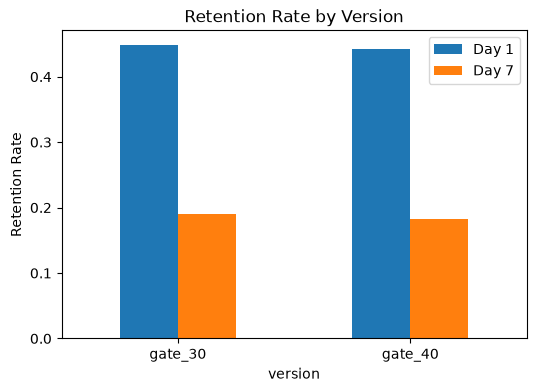

In [39]:
retention_rates.plot(kind='bar',figsize=(6,4))
plt.title('Retention Rate by Version')
plt.ylabel('Retention Rate')
plt.xticks(rotation=0)
plt.legend(['Day 1','Day 7'])
plt.show()

Hypotheses

**Retention Day 1**
- H0: No difference in Day-1 retention between gate_30 and gate_40
- H1: There is a difference in Day-1 retention between the two groups

**Retention Day 7**
- H0: No difference in Day-7 retention between gate_30 and gate_40
- H1: There is a difference in Day-7 retention between the two groups

Significance level: α = 0.05

In [42]:
from scipy import stats
import pandas as pd

def run_chi_square(df, retention_col):
    """
    Runs a chi-square test of independence between 'version' and a retention column.
    Tests whether retention is related to which gate version a player got.
    """
    
    contingency = pd.crosstab(df['version'], df[retention_col])
    
    
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    
    print(f"--- {retention_col} ---")
    print(contingency)                      
    print(f"Chi2 statistic: {chi2:.4f}")     
    print(f"P-value: {p:.4f}")               
    print()
    
    return chi2, p


chi2_1, p_1 = run_chi_square(df, 'retention_1')
chi2_7, p_7 = run_chi_square(df, 'retention_7')

--- retention_1 ---
retention_1  False  True 
version                  
gate_30      24666  20034
gate_40      25370  20119
Chi2 statistic: 3.1591
P-value: 0.0755

--- retention_7 ---
retention_7  False  True 
version                  
gate_30      36198   8502
gate_40      37210   8279
Chi2 statistic: 9.9591
P-value: 0.0016



In [43]:
from statsmodels.stats.proportion import proportions_ztest

def run_ztest(df, retention_col):
    """
    Runs a two-proportion z-test comparing retention rate between gate_30 and gate_40.
    """
    
    group_counts = df.groupby('version')[retention_col].agg(['sum', 'count'])
    
   
    successes = group_counts['sum'].values
    
    nobs = group_counts['count'].values
    
    
    z_stat, p_val = proportions_ztest(successes, nobs)
    
    print(f"--- {retention_col} (z-test) ---")
    print(f"Z-statistic: {z_stat:.4f}, P-value: {p_val:.4f}")
    
    return z_stat, p_val

run_ztest(df, 'retention_1')
run_ztest(df, 'retention_7')

--- retention_1 (z-test) ---
Z-statistic: 1.7841, P-value: 0.0744
--- retention_7 (z-test) ---
Z-statistic: 3.1644, P-value: 0.0016


(np.float64(3.164358912748191), np.float64(0.001554249975614329))

## Interpretation

- Retention Day 1: p = 0.0755 → fail to reject H0. No statistically significant 
  difference between gate_30 and gate_40 at α = 0.05.
- Retention Day 7: p = 0.0016 → reject H0. gate_30 shows significantly higher 
  Day-7 retention than gate_40 (19.0% vs 18.2%).

Effect size note: while Day-7 is statistically significant, the actual gap is 
0.8 percentage points — small in absolute terms, but meaningful at scale 
(90k+ daily active users).

##  Business Recommendation

**Recommendation: Do NOT move the gate from level 30 to level 40.**

**Why:**
- Day-1 retention showed no statistically significant difference (p = 0.0755), 
  so the gate change has no meaningful short-term impact.
- Day-7 retention was significantly lower for gate_40 (18.2%) vs gate_30 
  (19.0%), p = 0.0016. This is a real, not random, effect.
- At 90,000+ monthly players, a 0.8-point drop in 7-day retention translates 
  to roughly 720 fewer retained players per 90k cohort — a meaningful loss 
  at scale, even though the percentage gap looks small.

**Caveat:** The effect size is modest. This isn't a "the game is broken" 
result — it's a "don't make this change, it has a small but real negative 
cost" result. Worth monitoring if other business reasons (e.g. monetization 
at level 40) push toward making the change anyway.